#  Visualization and Reporting

In [1]:
import pandas as pd
df = pd.read_csv('ClusteredData.csv')

## Purchase categories

In [2]:
df_categories = df.copy()

In [3]:
# Splitting delimeter is ;
df_categories['Purchase_Categories'] = df_categories['Purchase_Categories'].str.split(';')

In [4]:
# Splitting gave us a list of separated categories
df_categories['Purchase_Categories'].head()

,Purchase_Categories
0,[Beauty and Personal Care]
1,"[Beauty and Personal Care, Clothing and Fashio..."
2,[Groceries and Gourmet Food]
3,"[Groceries and Gourmet Food, Beauty and Person..."
4,"[Groceries and Gourmet Food, Beauty and Person..."


In [5]:
# Splitting row wise for each category in the list
df_categories = df_categories.explode('Purchase_Categories')

In [6]:
# Clothing and Fashion is the Most Popular Product Category
# SnapDeal can do inventory planning prioritizing this category
df_categories['Purchase_Categories'].value_counts(normalize=True).round(4)*100

,proportion
Purchase_Categories,
Clothing and Fashion,22.97
Beauty and Personal Care,19.98
Home and Kitchen,19.55
others,19.11
Groceries and Gourmet Food,18.39


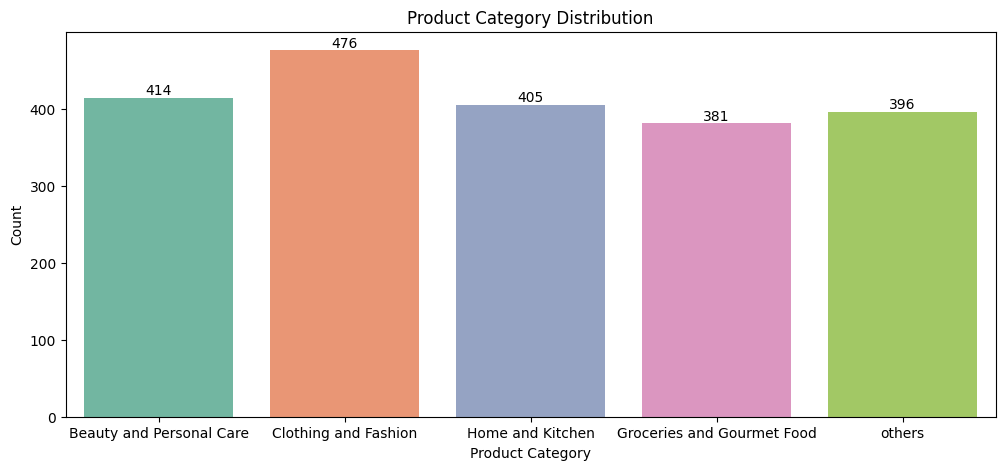

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(12,5))
ax = sns.countplot(data=df_categories,x='Purchase_Categories', hue='Purchase_Categories', palette='Set2')
for p in ax.containers:
  ax.bar_label(p)
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.title('Product Category Distribution')
plt.show()

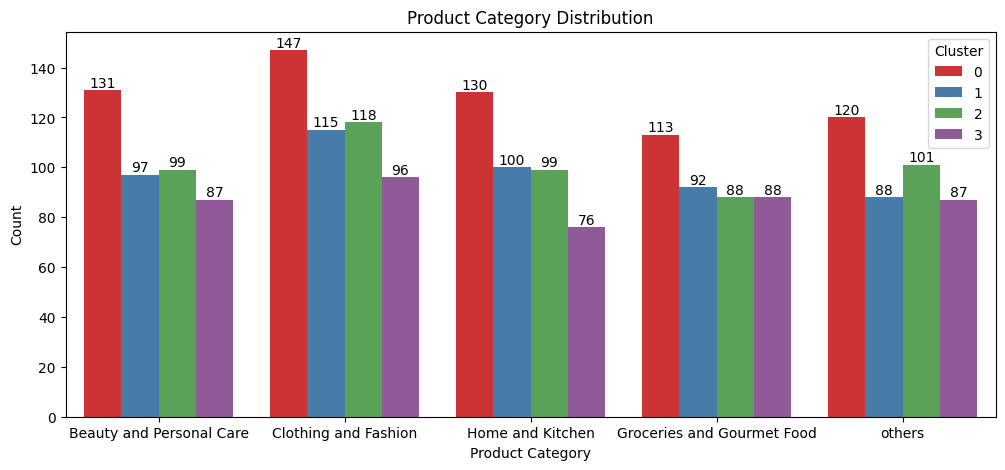

In [27]:
fig = plt.figure(figsize=(12,5))
ax = sns.countplot(data=df_categories,x='Purchase_Categories', hue='Cluster', palette='Set1')
for p in ax.containers:
  ax.bar_label(p)
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.title('Product Category Distribution')
plt.show()

## Browsing frequency distribution

In [13]:
df['Browsing_Frequency'].value_counts(normalize=True).round(4)*100

,proportion
Browsing_Frequency,
Multiple times a day,25.50
Few times a week,25.25
Few times a month,24.88
Rarely,24.38


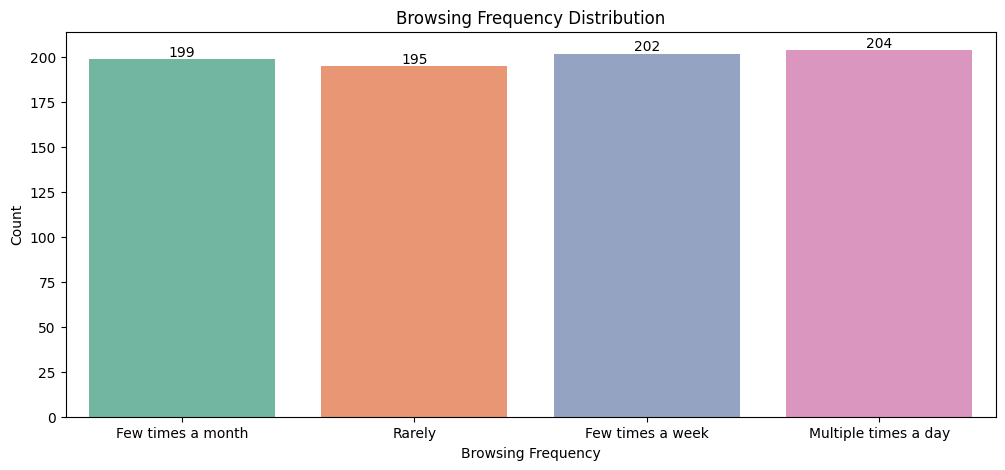

In [16]:
# More than 50% of Customers are browsing everyday or few times a week
fig = plt.figure(figsize=(12,5))
ax = sns.countplot(data=df,x='Browsing_Frequency', hue='Browsing_Frequency', palette='Set2')
for p in ax.containers:
  ax.bar_label(p)
plt.xlabel('Browsing Frequency')
plt.ylabel('Count')
plt.title('Browsing Frequency Distribution')
plt.show()

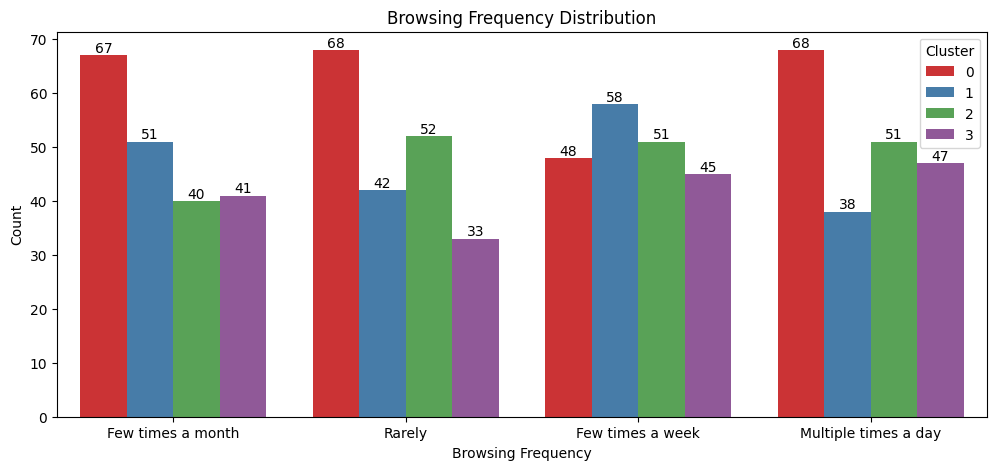

In [24]:
# Cluster 0 customers are dominantly browsing multiple times a day than others
fig = plt.figure(figsize=(12,5))
ax = sns.countplot(data=df,x='Browsing_Frequency', hue='Cluster', palette='Set1')
for p in ax.containers:
  ax.bar_label(p)
plt.xlabel('Browsing Frequency')
plt.ylabel('Count')
plt.title('Browsing Frequency Distribution')
plt.show()

## Satisfaction levels

In [19]:
# Most customers lie at satisfaction level 3 out of 5
df['Shopping_Satisfaction'].value_counts(normalize=True).round(4)*100

,proportion
Shopping_Satisfaction,
3,22.12
2,20.50
5,20.50
1,19.50
4,17.37


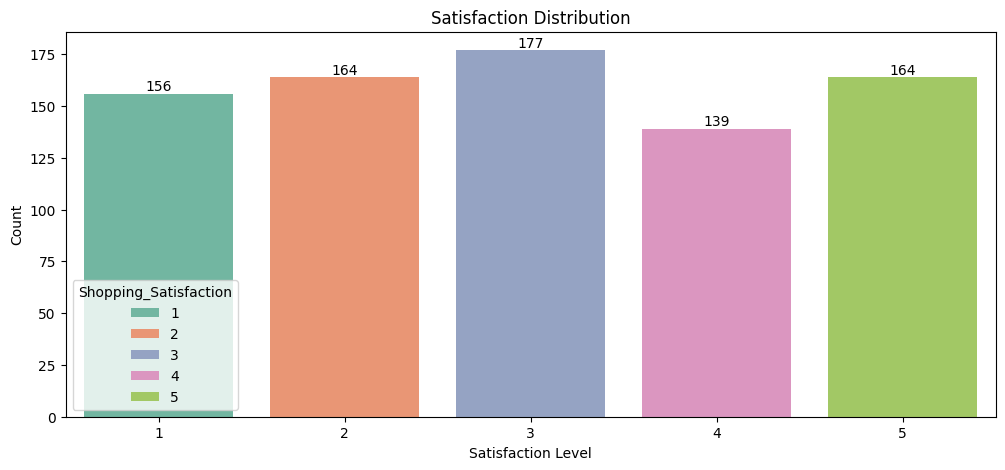

In [20]:
fig = plt.figure(figsize=(12,5))
ax = sns.countplot(data=df,x='Shopping_Satisfaction', hue='Shopping_Satisfaction', palette='Set2')
for p in ax.containers:
  ax.bar_label(p)
plt.xlabel('Satisfaction Level')
plt.ylabel('Count')
plt.title('Satisfaction Distribution')
plt.show()

## Correlation between recommendation helpfulness and satisfaction

In [31]:
rec = {'Yes': 3, 'No': 1, 'Sometimes': 2}
df['Recommendation_Helpfulness'] = df['Recommendation_Helpfulness'].map(rec)

In [33]:
# Almost negligible, slight positive Correlation
c = df[['Recommendation_Helpfulness','Shopping_Satisfaction']].corr()
c

,Recommendation_Helpfulness,Shopping_Satisfaction
Recommendation_Helpfulness,1.000000,0.040151
Shopping_Satisfaction,0.040151,1.000000


In [39]:
# Most customers fall in the category of NO helpfulness of the recommendations
# And their avg Satisfaction is also Low
# More Personalized and quality recommendation is required.
df.groupby('Recommendation_Helpfulness').agg({'Shopping_Satisfaction':['mean','count']})

Shopping_Satisfaction      
                                            mean count
Recommendation_Helpfulness                            
1                                       2.888136   295
2                                       3.077869   244
3                                       3.019157   261

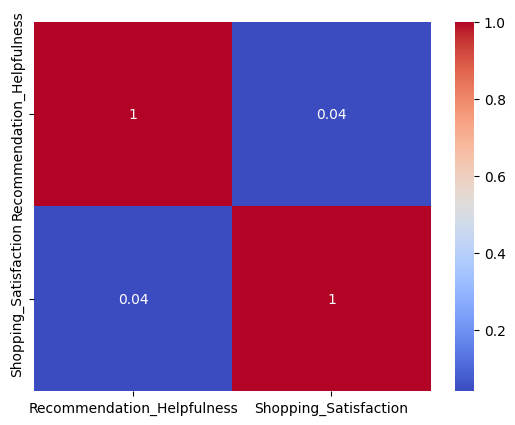

In [40]:
sns.heatmap(c, annot=True, cmap='coolwarm');